Importing the essential Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings

warnings.filterwarnings('error')

Importing the dataset for Analysis and a glance at the data

In [2]:
df_original = pd.read_csv('train_dataset_final1.csv')

df = df_original.copy()

df.head()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [3]:
df.drop(['Customer_ID'],axis=1,inplace=True)
df.rename(columns={'pay_0':"pay_1"},inplace=True)

<a id='eda'></a>
# Exploratory Data Analysis

we need to check for null values.

In [4]:
df.isnull().sum()

marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_1                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

As the age column has 126 null values. We will deal with these values by replacing them with median.

In [5]:
df['age']  = df['age'].fillna(df['age'].median())

df['age'].isnull().sum()

0


- marriage Marital status of the customer (1 = Married, 2 = Single, 3 = Others)
- Gender of the customer (1 = Male, 0 = Female)
- Education level (1 = Graduate School, 2 = University, 3 = High School, 4 = Others)
- Age of the customer (in years)

Checking the unique values in marriage, sex, education, cloumns



In [6]:
col = ['marriage','sex',"education"]

for i in col:
    print(f'{i} : {df[i].unique()}')

marriage : [2 1 3 0]
sex : [0 1]
education : [2 1 3 4 5 6 0]


In [7]:
#replacing extra info
df['marriage']=df['marriage'].replace({0:3})
df['education'] = df['education'].replace({0:4,5:4,6:4})

for i in col:
    print(f'{i} : {df[i].unique()}')

del col


marriage : [2 1 3]
sex : [0 1]
education : [2 1 3 4]


In [8]:
df[[f'pay_{i}' for i in range(1,7)]].describe()

,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6
count,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000
mean,-0.042857,-0.159544,-0.190359,-0.241415,-0.282568,-0.307680
std,1.099315,1.173990,1.172636,1.146753,1.114213,1.130864
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,7.000000,7.000000,8.000000


In [9]:
df['next_month_default'].value_counts()

next_month_default
0    20440
1     4807
Name: count, dtype: int64

 we see that the dataset we are dealing with is quite unbalanced, with only $4,807$ defaulters. This is a rather relevant problem that needs to be addressed. If neglected, classification models will tend to focus on the majority class and overlook the minority class 

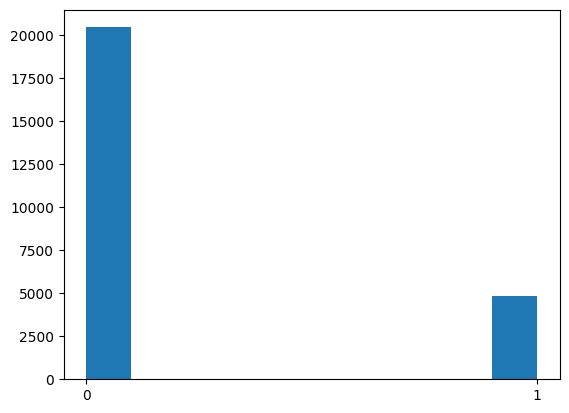

In [10]:
plt.hist(df['next_month_default'])
plt.xticks([0,1])
plt.show()

For the feature `age`, we draw a density map according to the default type, and the result is shown below.

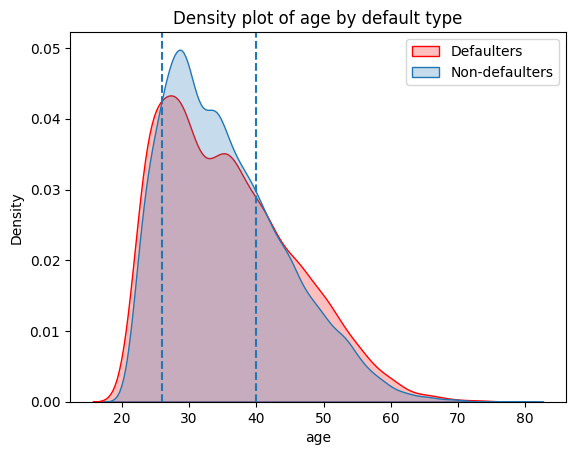

In [11]:

class_0 = df.loc[df['next_month_default'] == 0]['age']
class_1 = df.loc[df['next_month_default'] == 1]['age']


plt.title('Density plot of age by default type')

sns.kdeplot(class_1, fill=True, label='Defaulters', color='red')
sns.kdeplot(class_0, fill=True, label='Non-defaulters')

plt.axvline(26, 0, ls='--')
plt.axvline(40, 0, ls='--')
plt.legend()

plt.show()


For the feature `AGE`, we perform a similar visual analysis, as shown above on the right. The probability of non-default of age between approximately $25$ and $40$ is higher, which indicates that consumers in this age group are more capable of repaying credit card loans.

The features `sex` , `education` ,`marriage` are plotted according to target values.

visualizing the pay_i columns

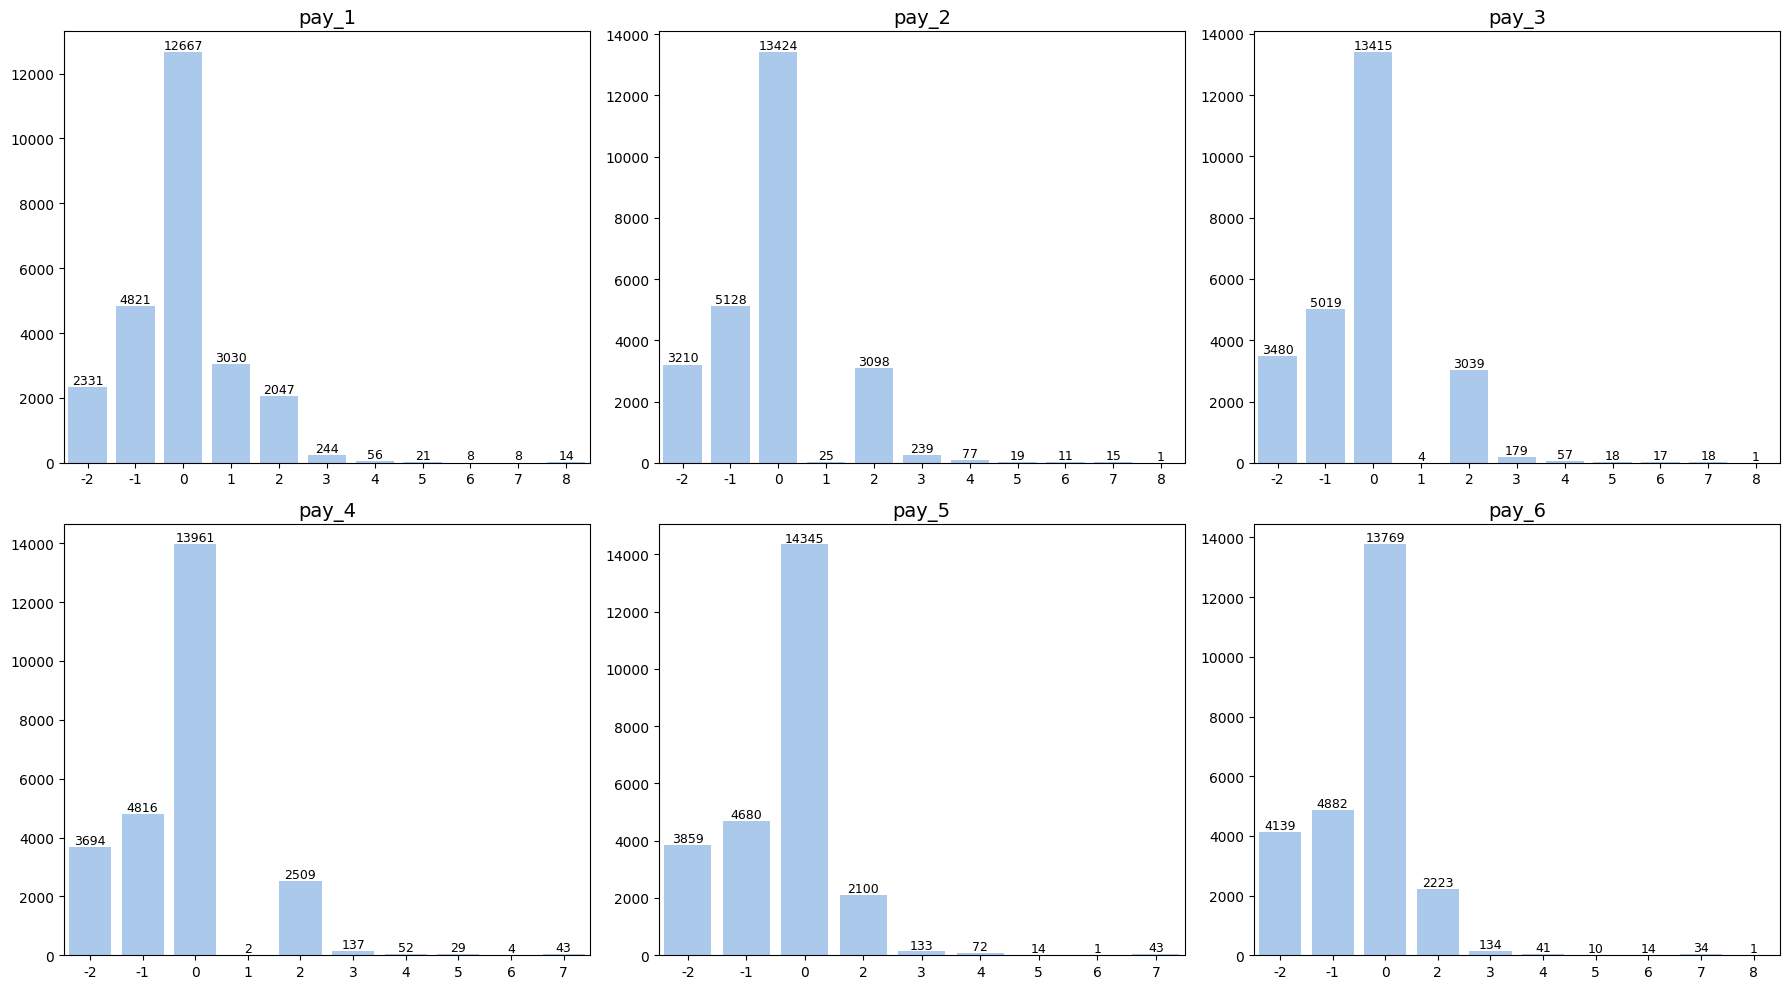

In [12]:
pay_cols = [f'pay_{i}' for i in range(1,7)]

# sns.set(style="whitegrid")
sns.set_palette("pastel")

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

axs = axs.flatten()

for i, col in enumerate(pay_cols):
    ax = axs[i]
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col, fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 100,  # adjust position
                f'{int(height)}', ha="center", fontsize=9)

# Improve spacing
plt.tight_layout()
plt.show()


Detecting outliers and Handling them

In [13]:
columns= ["age", "LIMIT_BAL",
    "Bill_amt1", "Bill_amt2", "Bill_amt3", "Bill_amt4", "Bill_amt5", "Bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6",
    "AVG_Bill_amt"]

for col in columns:
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    iqr = Q3-Q1
    lower = Q1 - 1.5*iqr
    upper = Q3 + 1.5*iqr
    df[col] = df[col].clip(lower,upper)
    

<Axes: >

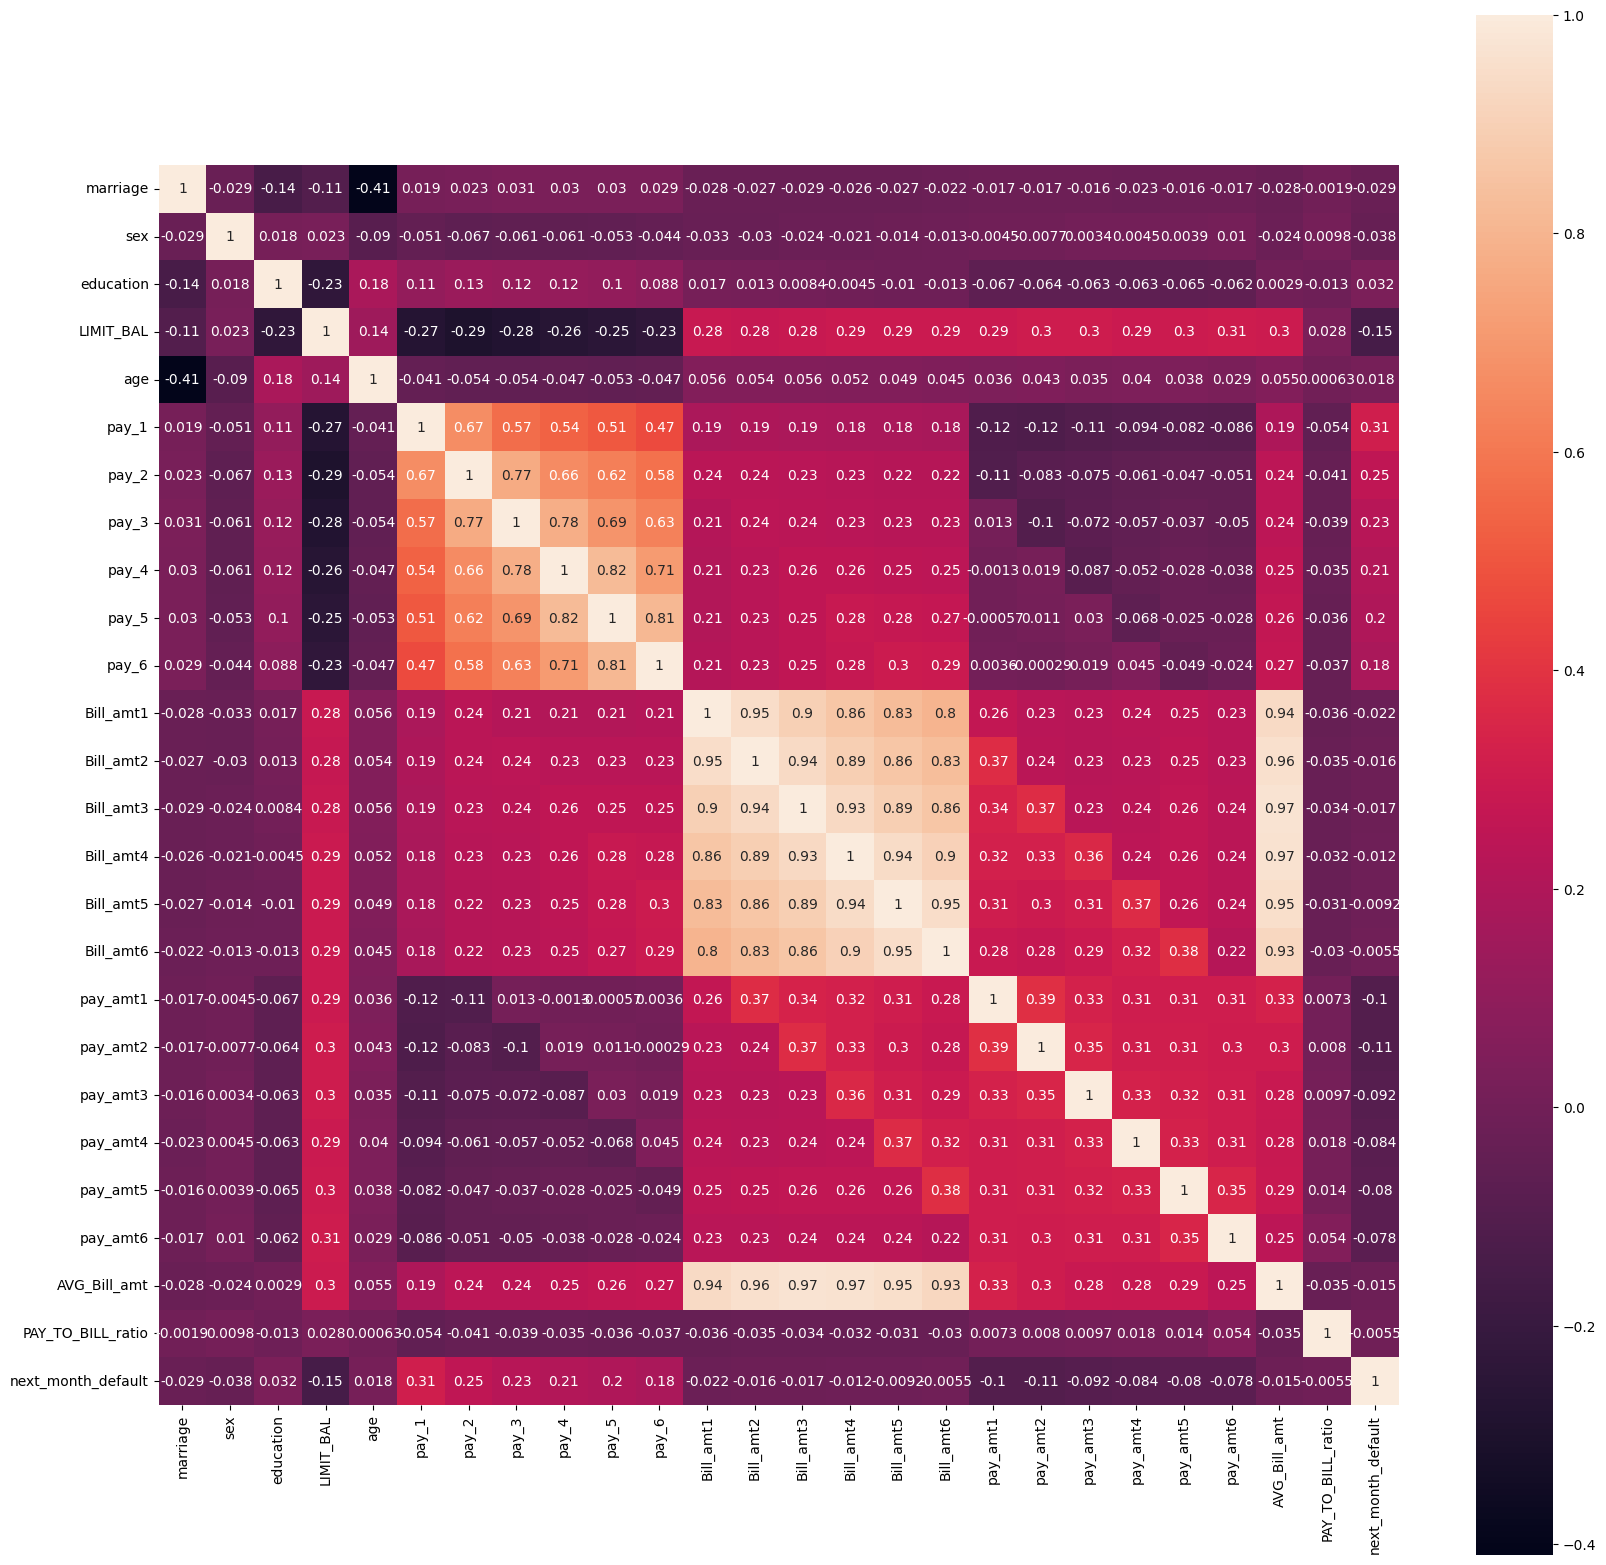

In [14]:
plt.figure(figsize = (20,20))     


sns.heatmap(df.corr(),annot = True,square = True)


<a id = 'Feature'></a>
# Feature Engineering
  

In [15]:
df['AVG_Pay_amt'] = (df['pay_amt1']+ df['pay_amt2']+df['pay_amt3']+df['pay_amt4']+df['pay_amt4']+df['pay_amt5']+df['pay_amt6'])/6

df['credit_utilization'] = np.where(df['LIMIT_BAL'] == 0, np.nan,
                                    df['AVG_Bill_amt'] / df['LIMIT_BAL'])
df['credit_utilization'] = df['credit_utilization'].fillna(df['credit_utilization'].median())



#Max streak of default
col = [f'{i}' for i in ['pay_1','pay_2','pay_3','pay_4','pay_5','pay_6']]
col = df[col].ge(1).astype(int)
def longest_streak(row):
    max_streak = streak = 0
    for val in row:
        if val == 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak
df['max_delinquency_streak'] = col.apply(longest_streak, axis=1)
df.head()

,marriage,sex,education,LIMIT_BAL,age,pay_1,pay_2,pay_3,pay_4,pay_5,...,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default,AVG_Pay_amt,credit_utilization,max_delinquency_streak
0,2,0,2,60000,25.0,2,2,2,0,0,...,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0,1629.815000,0.691858,3
1,2,1,1,290000,24.0,0,0,-2,-2,-1,...,0.00,2700.10,0.00,1349.72,2534.50,0.27,0,1125.015000,0.008740,0
2,1,0,2,180000,63.0,0,0,0,0,0,...,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0,2342.678333,0.280122,0
3,1,1,2,210000,43.0,0,0,0,0,0,...,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0,3522.245000,0.410617,0
4,2,0,1,280000,32.0,-2,-2,-2,-2,-2,...,45027.78,2100.09,0.01,0.27,11814.33,0.72,0,8902.381667,0.042194,0


<a id= 'preprocessing'></a>
# Data Preprocessing

In [16]:
x = df.drop('next_month_default',axis=1)
y = df['next_month_default']


Features with very low variance carry little information and are unlikely to be useful for prediction.
So we removed the columns with variance less then 0.1 in bellow cell.

In [17]:
from sklearn.feature_selection import VarianceThreshold

select = VarianceThreshold(threshold=0.1)

x_vfilter = select.fit_transform(x)

features_aft_var = x.columns[select.get_support()]

x = x[features_aft_var]
x.shape

(25247, 28)

As seen in heatmap ,there are many highly correlated features and
highly correlated features are redundant and may cause multicollinearity problems in models.
So we removed them using sklearn.

In [18]:
corr_matrix = x.corr().abs()

upper_lim = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

dropables = [column for  column in upper_lim.columns if any(upper_lim[column] > 0.9)]

x  = x.drop(columns = dropables)

x.shape

(25247, 22)

<Axes: >

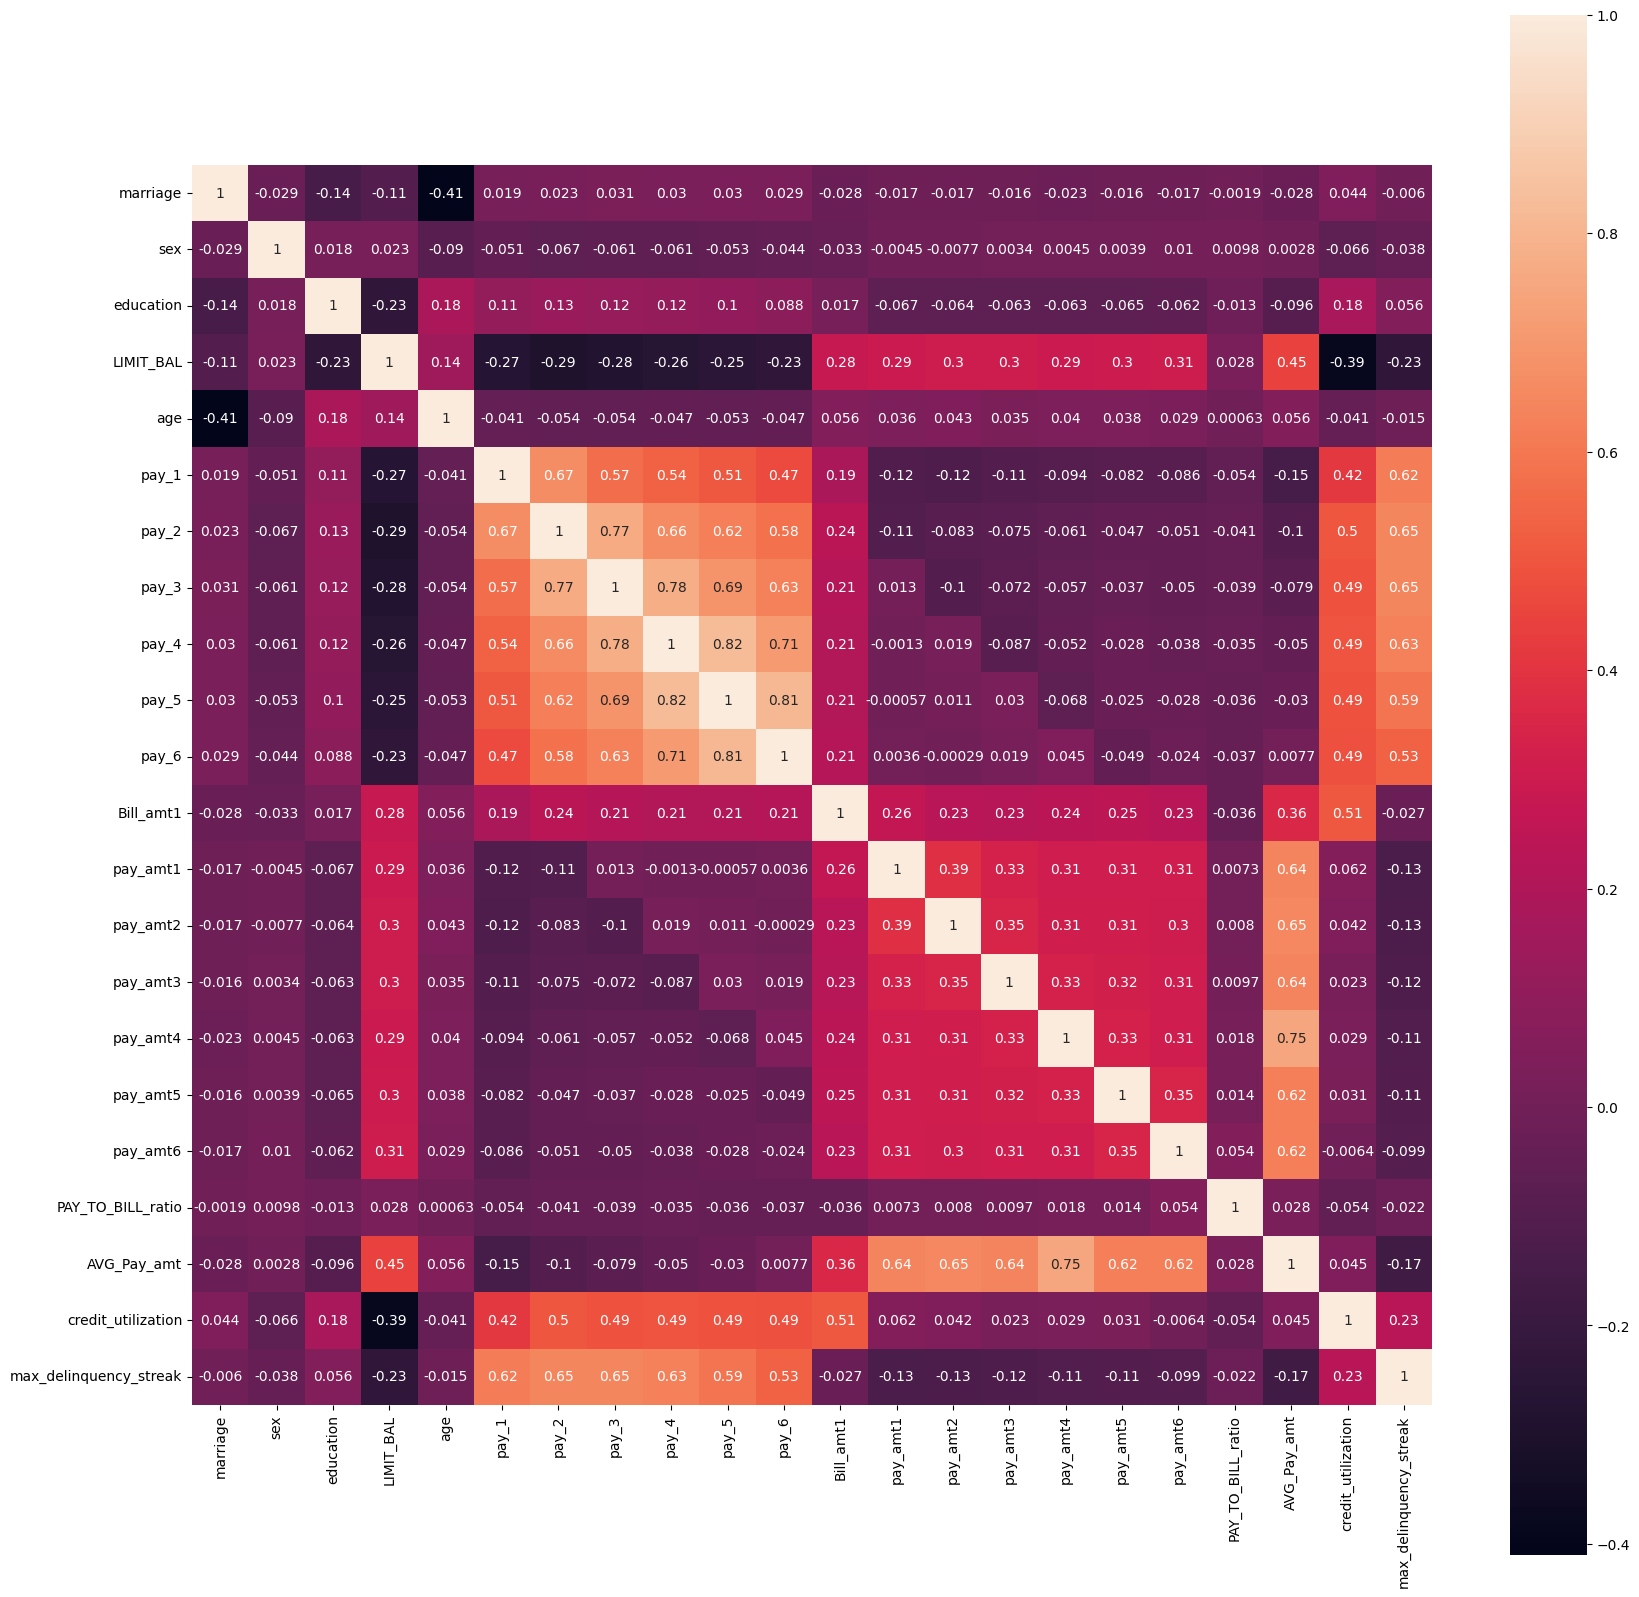

In [19]:
plt.figure(figsize = (20,20))     
sns.heatmap(x.corr(),annot = True,square = True)

Applying one hot encoding on categorical features :- `sex`,`education`,`marriage`

In [20]:
colums = x.columns
cat_colms = ['sex','marriage','education']
num_colms = [i for i in colums if i not in cat_colms]

x = pd.get_dummies(x,columns= cat_colms ,drop_first = True ).astype(int)

Spliting the Dataset

In [21]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=24,stratify=y,shuffle=True)


As seen above the defaulters and non- defaulters class is highly imbalanced so applying SMOTE technique to balance the classes.

In [22]:
x_train.head()

,LIMIT_BAL,age,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,pay_amt1,...,PAY_TO_BILL_ratio,AVG_Pay_amt,credit_utilization,max_delinquency_streak,sex_1,marriage_2,marriage_3,education_2,education_3,education_4
16733,500000,49,-1,-1,-1,-1,-1,-1,4006,10020,...,1,38699,0,0,1,0,0,0,0,0
17335,50000,41,0,0,0,0,0,0,47740,1999,...,0,1804,0,0,1,0,0,0,0,0
16362,50000,38,0,0,0,0,0,0,22618,1999,...,0,1666,0,0,0,0,0,1,0,0
15398,230000,24,0,0,0,0,2,0,82065,3999,...,0,3216,0,1,0,1,0,0,1,0
7812,230000,30,-1,-1,-2,-2,-2,-1,2379,0,...,1,7514,0,0,1,1,0,0,1,0


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_sampled,y_sampled = smote.fit_resample(x_train,y_train)

y_sampled.value_counts()

next_month_default
0    16352
1    16352
Name: count, dtype: int64

scaling the Numerical columns

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_sampled[num_colms] = scaler.fit_transform(x_sampled[num_colms])

x_test[num_colms] =scaler.transform(x_test[num_colms])


<a id = 'Model'></a>
# Model Evaluation

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
models ={
    #logistic Regression
    'lr' :LogisticRegression(
        class_weight='balanced',
        C=0.1,
        max_iter=1000,
        random_state=42
        ),
    
    # Random Forest with tuned parameters
    'rf' : RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
        ),
    
    # Gradient Boosting
    'gb' : GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    
    # Improved Neural Network
   'mlp' : MLPClassifier(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
    
    # XGBoost
    'xg' : XGBClassifier()
}



In [26]:
from sklearn.metrics import f1_score ,fbeta_score

def threshold_and_result(model,x_test,y_test):
    y_proba = model.predict_proba(x_test)[:, 1] 

    thresholds = np.arange(0.1, 0.91, 0.05)
    results = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)
        f2 = fbeta_score(y_test,y_pred,beta=2)
        results.append({'threshold': threshold, 'f1_score': f1 , 'f2_score': f2})

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df['f2_score'].idxmax()]
    best_threshold = best_row['threshold']
    best_f1 = best_row['f2_score']

    return best_threshold, (y_proba >= best_threshold).astype(int)

In [27]:
from sklearn.metrics import accuracy_score,f1_score,fbeta_score,classification_report,confusion_matrix



def model_train(models,x_train,y_train,x_test,y_test):
    results = {}
    models_names = ['lr','rf','gb','mlp','xg']
    
    for mod in models_names:
        model = models[mod]
        model.fit(x_train,y_train)
        threshold,y_pred = threshold_and_result(model,x_test,y_test)

        results[mod] = {
                        "threshold" : threshold,
                        "accuracy"  : accuracy_score(y_test,y_pred),
                        "f1_score"  : f1_score(y_test,y_pred),
                        'f2_score'  : fbeta_score(y_test,y_pred,beta=2),
                        "confusion_matrix" :confusion_matrix(y_test,y_pred),
                        "Classification report" : classification_report(y_test,y_pred)
        }
    return results
        


In [28]:
results = model_train(models,x_sampled,y_sampled,x_test,y_test)

for i in results:
     print(results[i])

{'threshold': 0.15000000000000002, 'accuracy': 0.3499009900990099, 'f1_score': 0.3469265963795504, 'f2_score': 0.5509920384177935, 'confusion_matrix': array([[ 895, 3193],
       [  90,  872]], dtype=int64), 'Classification report': '              precision    recall  f1-score   support\n\n           0       0.91      0.22      0.35      4088\n           1       0.21      0.91      0.35       962\n\n    accuracy                           0.35      5050\n   macro avg       0.56      0.56      0.35      5050\nweighted avg       0.78      0.35      0.35      5050\n'}
{'threshold': 0.20000000000000004, 'accuracy': 0.5067326732673267, 'f1_score': 0.3975816203143894, 'f2_score': 0.585386697051702, 'confusion_matrix': array([[1737, 2351],
       [ 140,  822]], dtype=int64), 'Classification report': '              precision    recall  f1-score   support\n\n           0       0.93      0.42      0.58      4088\n           1       0.26      0.85      0.40       962\n\n    accuracy               

<a id ='selection'> </a>
# Model Selection

In [29]:
f2_scores = {}
for i in results:
    f2_scores[i] = results[i]['f2_score']


f2_scores

{'lr': 0.5509920384177935,
 'rf': 0.585386697051702,
 'gb': 0.5659586361095584,
 'mlp': 0.5412688635663689,
 'xg': 0.5617548150412718}

So the best model based on f2 score is `rf` : `RandomForestClassifier`.

In [30]:
best_model = models['rf']
best_threshold  = results['rf']['threshold']
best_model_result = results['rf']

for re in best_model_result:
    print(f"{re} : \n \t{best_model_result[re]} \n")
print(best_model_result)

threshold : 
 	0.20000000000000004 

accuracy : 
 	0.5067326732673267 

f1_score : 
 	0.3975816203143894 

f2_score : 
 	0.585386697051702 

confusion_matrix : 
 	[[1737 2351]
 [ 140  822]] 

Classification report : 
 	              precision    recall  f1-score   support

           0       0.93      0.42      0.58      4088
           1       0.26      0.85      0.40       962

    accuracy                           0.51      5050
   macro avg       0.59      0.64      0.49      5050
weighted avg       0.80      0.51      0.55      5050
 

{'threshold': 0.20000000000000004, 'accuracy': 0.5067326732673267, 'f1_score': 0.3975816203143894, 'f2_score': 0.585386697051702, 'confusion_matrix': array([[1737, 2351],
       [ 140,  822]], dtype=int64), 'Classification report': '              precision    recall  f1-score   support\n\n           0       0.93      0.42      0.58      4088\n           1       0.26      0.85      0.40       962\n\n    accuracy                           0.51      5

<a id = 'validation'></a>
# Calculating Validation Dataset Results

In [31]:

df = pd.read_csv("validate_dataset_final.csv")

customer_ID = df['Customer_ID']

df.drop(['Customer_ID'],axis=1,inplace=True)
df.rename(columns={'pay_0':"pay_1"},inplace=True)

col = ['marriage','sex',"education"]

for i in col:
    print(f'{i} : {df[i].unique()}')

# %%
#replacing extra info
df['marriage']=df['marriage'].replace({0:3})
df['education'] = df['education'].replace({0:4,5:4,6:4})

for i in col:
    print(f'{i} : {df[i].unique()}')
del col

columns= ["age", "LIMIT_BAL",
    "Bill_amt1", "Bill_amt2", "Bill_amt3", "Bill_amt4", "Bill_amt5", "Bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6",
    "AVG_Bill_amt"]

for col in columns:
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    iqr = Q3-Q1
    lower = Q1 - 1.5*iqr
    upper = Q3 + 1.5*iqr
    df[col] = df[col].clip(lower,upper)


marriage : [1 2 3 0]
sex : [1 0]
education : [2 1 3 4 5 0 6]
marriage : [1 2 3]
sex : [1 0]
education : [2 1 3 4]


In [32]:
df['AVG_Pay_amt'] = (df['pay_amt1']+ df['pay_amt2']+df['pay_amt3']+df['pay_amt4']+df['pay_amt4']+df['pay_amt5']+df['pay_amt6'])/6

df['credit_utilization'] = np.where(df['LIMIT_BAL'] == 0, np.nan,
                                    df['AVG_Bill_amt'] / df['LIMIT_BAL'])
df['credit_utilization'] = df['credit_utilization'].fillna(df['credit_utilization'].median())

col = [f'{i}' for i in ['pay_1','pay_2','pay_3','pay_4','pay_5','pay_6']]
col = df[col].ge(1).astype(int)
def longest_streak(row):
    max_streak = streak = 0
    for val in row:
        if val == 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak
df['max_delinquency_streak'] = col.apply(longest_streak, axis=1)

x = df

#removing low variance
x = x[features_aft_var]

x  = x.drop(columns = dropables)

colums = x.columns
cat_colms = ['sex','marriage','education']
num_colms = [i for i in colums if i not in cat_colms]

x = pd.get_dummies(x,columns= cat_colms ,drop_first = True ).astype(int)

x[num_colms] = scaler.transform(x[num_colms])

best_model.fit(x_sampled,y_sampled)

y_proba = best_model.predict_proba(x)[:, 1]
y_pred  = (y_proba>0.25).astype(int)



In [33]:
final_df = pd.DataFrame(customer_ID)
final_df['next_month_default'] = y_pred

In [34]:
final_df.to_csv("submission_23116046.csv")